<a href="https://colab.research.google.com/github/Emmanuel2211/.config/blob/master/Entregable_Tarea_5_1_Alfaro_Cruz_P%C3%A9rez_Rupit_Medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Exploración y Preprocesamiento
15% Manejo adecuado de valores nulos, codificación de categóricas y escalamiento de variables (crítico para GLM, L1/$L_2$ y Redes Neuronales).

## Resumen de la programación realizada en este código

1) ashdgjasgdjha
2) ajsdajhds


In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas

In [ ]:
# Importar la información
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

for int i


In [ ]:
# Mostrar las primeras 5 filas
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


# Glosario de Columnas Relevantes

pm2.5 --> PM25: Concentración de partículas PM2.5 (material particulado fino)

DEWP: Punto de rocío (Dew Point)

TEMP: Temperatura ambiente

PRES: Presión atmosférica

cbwd --> WIND_DIRECTION : Dirección combinada del viento

lws --> WIND_SPEED: velocidad acumulada del viento

ls: Horas acumuladas de nieve

lr: Horas acumuladas de lluvia

 -NW: Viento del noroeste

 -NE: Viento del noreste

 -SE: Viento del sureste

 -cv: Calm Variable (viento muy debil o dirección variable). *Combinación de las tres anteriores, sin rumbo fijo.

In [ ]:
# Revisar el tipos de datos y columnas presentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [ ]:
#Renombrar encabezados
df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WINSD_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.info()  # Revisar el tipos de datos y columnas presentes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   year            43824 non-null  int64  
 2   month           43824 non-null  int64  
 3   day             43824 non-null  int64  
 4   hour            43824 non-null  int64  
 5   PM25            41757 non-null  float64
 6   DEWPOINT        43824 non-null  int64  
 7   TEMP            43824 non-null  float64
 8   PRESION         43824 non-null  float64
 9   WIND_DIRECTION  43824 non-null  object 
 10  WINSD_SPEED     43824 non-null  float64
 11  SNOW            43824 non-null  int64  
 12  RAIN            43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [ ]:
# Crear una columna con la fecha a partir de year, month, day y hour
# Mostrar resultados
df['fecha'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']]) # Crea una columna con la fecha
print("Rango de fechas del dataset:")
print(f"Desde: {df['fecha'].min()} hasta {df['fecha'].max()}")

Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 23:00:00


In [ ]:
# Análisis de métricas principales de la información
df.drop(columns=["NO", "year", "month", "day", "hour"]).describe()   # Estadísticas básicas sin considerar las fechas

,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


Nota: El rango de las variables (diferente entre ellas) puede afectar el modelo por lo que es posible que se deba normalizar

In [ ]:
|# Revisión de datos nulos de la información
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,2067
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [ ]:
# Porcentaje de vacíos en la información por modelar
2067/43824

0.04716593647316539

Sólo la variable por modelar tiene valores nulos y es menos del 4.72%

Text(0.5, 0, 'Concentración μg/m³')

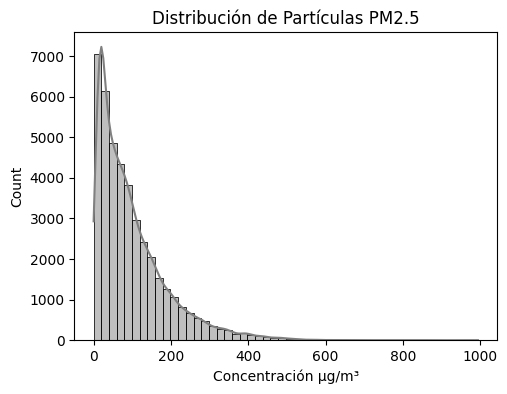

In [ ]:
# Configuración de los gráficos
plt.figure(figsize=(12, 4))

# 1. Gráfico para ver la distribución de PM2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 1)
sns.histplot(df['pm2.5'].dropna(), bins=50, kde=True, color='grey')
plt.title('Distribución de Partículas PM2.5')
plt.xlabel('Concentración μg/m³')

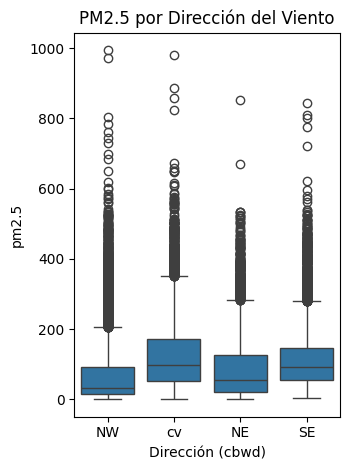

In [ ]:
# 2. Gráfico de caja para ver cómo afecta el viento en calma ('cv') frente a los otros a las PM2.5
plt.subplot(1, 2, 2)
sns.boxplot(x='cbwd', y='pm2.5', data=df)
plt.title('PM2.5 por Dirección del Viento')
plt.xlabel('Dirección (cbwd)')
plt.tight_layout()
plt.show()

ConversionError: Failed to convert value(s) to axis units: array(['NW', 'NW', 'NW', ..., 'NW', 'NW', 'NW'], dtype=object)

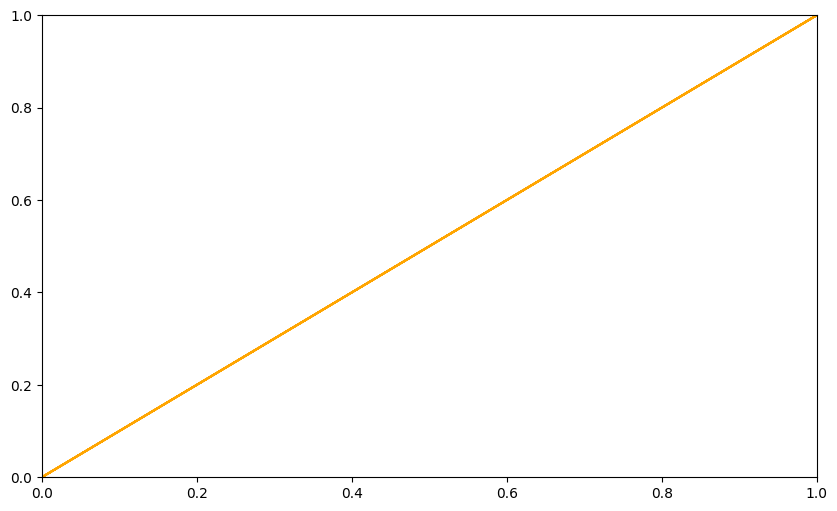

In [ ]:
# Crear un índice con la fecha
df_temporal = df.set_index('fecha') # Hacer un índice con la fecha
# Graficar dos columnas en la misma serie temporal
plt.figure(figsize=(10,6))
plt.plot(df_temporal, df["pm2.5"], label='Concentración', color='orange')
plt.plot(df_temporal, df['DEWP'], label='Rocío', color='grey')

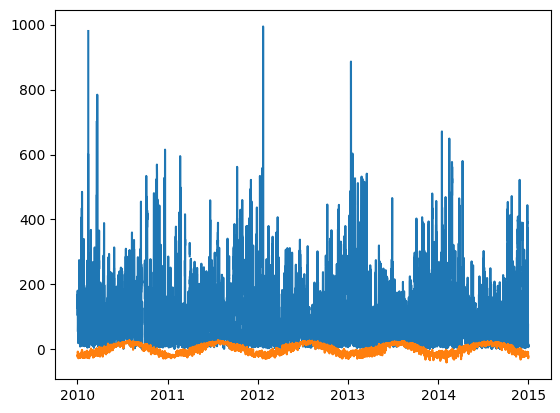

In [ ]:
plt.plot(df["fecha"], df["pm2.5"], label="PM2.5")
plt.plot(df["fecha"], df["DEWP"], label="DEWP")

In [ ]:
# Rellenar nulos con la mediana
# df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].median())

Opción 1: Eliminar nulos

Opción 2: Rellenar con la media

Opción 3: Rellenar con interpolación temporal

In [ ]:
OPCIÓN 1: